# Ejercicio 7: Análisis y comparación de los lagos

In [5]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

from src.config import LAGOS

plt.rcParams["figure.dpi"] = 100

tabla = pd.read_csv("../data/processed/tabla_temporal.csv", parse_dates=["fecha"])
tabla


,lago,fecha,ndvi,ndwi,cianobacteria,pct_agua
0,amatitlan,2025-01-28,-0.346851,0.560614,16.570559,12.049362
1,amatitlan,2025-04-15,-0.072402,0.261397,8.546434,12.049362
2,amatitlan,2025-04-28,-0.030968,0.252395,13.707850,12.049362
3,amatitlan,2025-11-24,-0.346610,0.494686,14.737459,12.049362
4,amatitlan,2026-01-08,-0.056008,0.323024,26.251829,12.049362
5,amatitlan,2026-02-02,-0.027839,0.137676,6.884248,12.049362
6,amatitlan,2026-02-07,-0.239680,0.417715,10.022497,12.049362
7,amatitlan,2026-03-29,-0.051128,0.290851,15.552852,12.049362
8,amatitlan,2026-04-13,-0.011525,0.265592,17.129589,12.049362
9,amatitlan,2026-04-28,0.054311,0.228508,26.605566,12.049362


## 7.1 Proliferación de cianobacteria por lago

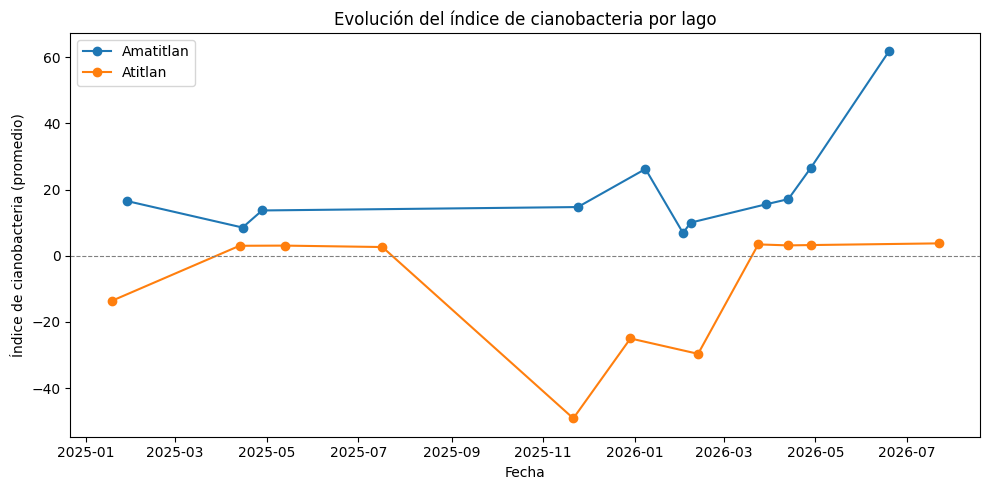

,media,desviacion,minimo,maximo,n_fechas_positivas,n_fechas_totales
lago,,,,,,
amatitlan,19.805903,15.310302,6.884248,61.856045,11,11
atitlan,-8.638136,18.315286,-49.142479,3.757445,7,11


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for lago, g in tabla.groupby("lago"):
    ax.plot(g["fecha"], g["cianobacteria"], marker="o", label=lago.capitalize())
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice de cianobacteria (promedio)")
ax.set_title("Evolución del índice de cianobacteria por lago")
ax.legend()
plt.tight_layout()
plt.show()

resumen_71 = tabla.groupby("lago")["cianobacteria"].agg(
    media="mean", desviacion="std", minimo="min", maximo="max"
)
resumen_71["n_fechas_positivas"] = tabla.groupby("lago")["cianobacteria"].apply(lambda s: (s > 0).sum())
resumen_71["n_fechas_totales"] = tabla.groupby("lago")["cianobacteria"].size()
resumen_71


**Amatitlán** muestra un índice de cianobacteria consistentemente positivo en las 11 fechas analizadas (media = 19.8, rango 6.9–61.9), sin caer nunca a valores cercanos a cero. Esto es compatible con un lago en estado eutrófico crónico, donde la señal de pigmentos fotosintéticos asociados a floraciones está presente de forma persistente y no solo en episodios puntuales. El pico de 2026-06-19 (61.9) coincide con la fecha de mayor nubosidad de toda la serie de Amatitlán (13.0%, frente a <5% en el resto), por lo que debe tratarse como una fecha crítica a interpretar con cautela: parte de ese valor extremo podría deberse a contaminación por bordes de nube y no únicamente a una floración real.

**Atitlán**, en cambio, oscila mayormente alrededor de cero y solo es positivo en 7 de las 11 fechas, con valores máximos muy bajos (=3.8) que no se acercan a los niveles sostenidos de Amatitlán. Las fechas más negativas (2025-11-21 = −49.1 y 2026-02-12 = −29.6) no coinciden con nubosidad alta (3.15% y 0.04% respectivamente), por lo que probablemente no son artefactos de nubes; una explicación más plausible es que la fórmula empírica de cianobacteria (calibrada típicamente sobre reservorios turbios/eutróficos) se comporta de forma menos estable en un lago profundo y ópticamente muy distinto como Atitlán, generando valores fuera del rango para el que el modelo fue diseñado. En conjunto, la evidencia no sugiere proliferación relevante de cianobacteria en Atitlán durante el período estudiado.

## 7.2 Comparación de intensidad y frecuencia de floraciones

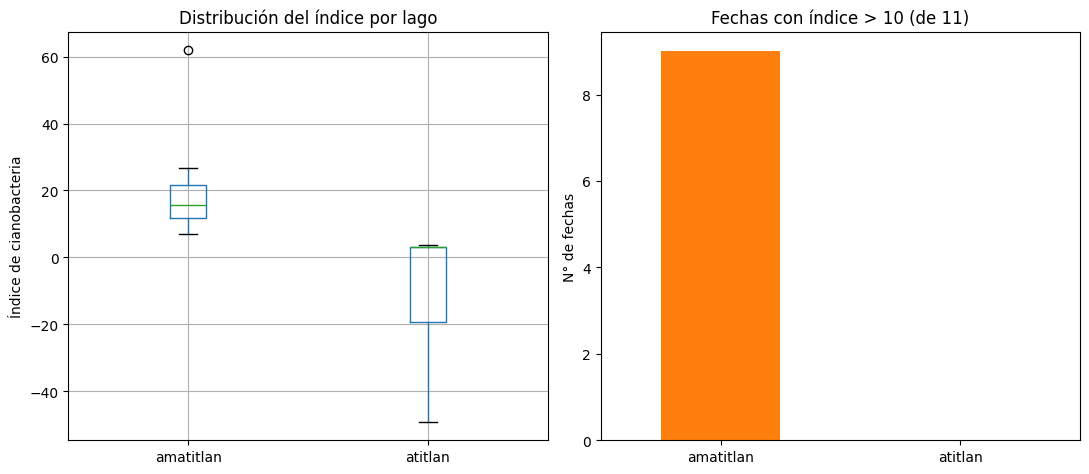

Fechas con indice > 10:
lago
amatitlan    9
atitlan      0
Name: cianobacteria, dtype: int64

Amplitud (max - min) por lago:
lago
amatitlan    54.971797
atitlan      52.899924
Name: cianobacteria, dtype: float64


In [7]:
UMBRAL_FLORACION = 10  

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

tabla.boxplot(column="cianobacteria", by="lago", ax=axes[0])
axes[0].set_title("Distribución del índice por lago")
axes[0].set_xlabel("")
axes[0].set_ylabel("Índice de cianobacteria")

frecuencia = tabla.groupby("lago")["cianobacteria"].apply(lambda s: (s > UMBRAL_FLORACION).sum())
frecuencia.plot(kind="bar", ax=axes[1], color=["tab:orange", "tab:blue"])
axes[1].set_title(f"Fechas con índice > {UMBRAL_FLORACION} (de 11)")
axes[1].set_ylabel("N° de fechas")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"Fechas con indice > {UMBRAL_FLORACION}:")
print(frecuencia)
print("\nAmplitud (max - min) por lago:")
print(tabla.groupby("lago")["cianobacteria"].apply(lambda s: s.max() - s.min()))


En frecuencia, Amatitlán supera el umbral de floración notable (índice > 10) en 9 de las 11 fechas (=82%), mientras que Atitlán no lo supera en ninguna (0 de 11). En intensidad, la mediana de Amatitlán se ubica claramente por encima de cero y de la de Atitlán, que se mantiene pegada a cero.

Vale la pena notar que la desviación estándar de Atitlán (=18.3) es mayor que la de Amatitlán (=15.3), y que el rango total (max−min) de ambos lagos es parecido en magnitud (=52.9 en Atitlán vs. =55.0 en Amatitlán), visible en el boxplot como una caja de Atitlán más comprimida pero con outliers extremos hacia abajo. Esto **no** indica mayor proliferación en Atitlán: su dispersión está dominada por valores muy negativos (posibles artefactos del modelo, ver 7.1), no por picos positivos de floración, mientras que la de Amatitlán está dominada por picos positivos reales. Por eso la comparación de frecuencia sobre el umbral positivo es más informativa que la desviación estándar o el rango crudos para este caso.

## 7.3 Posibles diferencias en las causas de la proliferación

- **Geografía y morfología:** Atitlán es un lago volcánico profundo (>300 m en su punto más profundo), con una cuenca cerrada y sin salida superficial permanente. Su gran volumen y profundidad favorecen la estratificación térmica y limitan la mezcla de nutrientes hacia la superficie, lo que reduce la disponibilidad de nutrientes para floraciones algales frecuentes. Amatitlán, en cambio, es un lago somero (profundidad media de solo 15–18 m), lo que facilita la resuspensión de sedimentos y nutrientes hacia la columna de agua iluminada, favoreciendo el crecimiento algal.

- **Uso del suelo y presión urbana:** la cuenca de Amatitlán está dentro del área metropolitana de la Ciudad de Guatemala, con alta densidad poblacional, descargas históricas de aguas residuales domésticas e industriales, y escorrentía agrícola, todas fuentes de nitrógeno y fósforo que alimentan floraciones de cianobacterias. La cuenca de Atitlán tiene menor densidad poblacional y menos industria pesada, aunque enfrenta presión creciente por turismo y crecimiento urbano en sus orillas.

- **Clima y temperatura:** ambos lagos están en tierras altas de Guatemala, pero Amatitlán se encuentra a menor elevación (1,190 msnm) que Atitlán (1,560 msnm), lo que implica temperaturas del agua ligeramente más cálidas en Amatitlán, un factor que favorece el crecimiento de cianobacterias, que suelen proliferar más en aguas cálidas y ricas en nutrientes.

- **Consistencia con el análisis de correlación:** en Atitlán se encontró una correlación negativa fuerte entre NDWI y cianobacteria (r = −0.79), consistente con un lago de aguas profundas y transparentes donde mayor señal de "agua limpia" se asocia a menor señal de cianobacteria. En Amatitlán no se encontraron correlaciones significativas con NDVI/NDWI, lo que sugiere que su proliferación depende más de factores externos (cargas de nutrientes, temperatura) que de la señal óptica general del agua, coherente con un lago eutrófico donde la floración es casi permanente y no varía tanto en función de esas variables.

## 7.4 Conclusiones sustentadas en evidencia

In [8]:
evidencia = tabla.groupby("lago")["cianobacteria"].agg(
    media="mean", desviacion="std", minimo="min", maximo="max"
)
evidencia["n_positivas"] = tabla.groupby("lago")["cianobacteria"].apply(lambda s: (s > 0).sum())
evidencia[f"n_mayor_{UMBRAL_FLORACION}"] = frecuencia
evidencia["n_total_fechas"] = tabla.groupby("lago")["cianobacteria"].size()
evidencia


,media,desviacion,minimo,maximo,n_positivas,n_mayor_10,n_total_fechas
lago,,,,,,,
amatitlan,19.805903,15.310302,6.884248,61.856045,11,9,11
atitlan,-8.638136,18.315286,-49.142479,3.757445,7,0,11


Con base en la evidencia cuantitativa (tabla anterior), los gráficos temporales (7.1), los mapas espaciales del ejercicio 5 y las correlaciones del ejercicio 6, se concluye que:

1. **Amatitlán presenta proliferación de cianobacteria crónica, no episódica**: índice positivo en el 100% de las fechas (11/11), con media =19.8 y 9/11 fechas por encima del umbral de floración notable. Los mapas de zonas persistentes (ejercicio 5.3) deberían mostrarse aquí junto a esta tabla para localizar espacialmente dónde se concentra esa señal dentro del lago.

2. **Atitlán no muestra evidencia de proliferación relevante** en el período estudiado: 0/11 fechas superan el umbral, y la mediana se mantiene cerca de cero. Los valores negativos extremos observados son puntuales y probablemente reflejan limitaciones del modelo de cianobacteria fuera de su rango de calibración, no floraciones "inversas".

3. **La diferencia es consistente**: Amatitlán combina menor profundidad, mayor presión urbana/de aguas residuales y menor elevación (agua más cálida), mientras que Atitlán, profundo, de cuenca cerrada y con menor carga antropogénica directa sobre el espejo de agua, presenta condiciones mucho menos favorables para la cianobacteria.

4. **Recomendación de monitoreo**: dado que Amatitlán no baja nunca de niveles moderados, el monitoreo ahí debería enfocarse en identificar picos agudos (como el de 2026-06-19, a confirmar si es real o artefacto de nubes) más que en detectar el inicio de una floración. En Atitlán, en cambio, el monitoreo debería enfocarse en detectar cualquier cambio de tendencia sostenido, ya que actualmente se encuentra en un estado de base sin señal de floración.
